# Demo code for Wingert, Parida et al. 2026

In [1]:
import os
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import wilcoxon
from sklearn.decomposition import PCA

# Functions from NEMS library
from nems.tools.recording import load_recording, average_away_epoch_occurrences
from nems.preprocessing.normalization import log_compress
from nems.preprocessing.filters import smooth

from nems.tools.json import load_model
from nems.tools import dstrf
from nems.models import base, LN, CNN
from nems.metrics import correlation

# special functions used to generate plots in this study
import aud_ss_tools

font_size=8
params = {'legend.fontsize': font_size-2,
          'figure.figsize': (8, 6),
          'axes.labelsize': font_size,
          'axes.titlesize': font_size,
          'axes.spines.right': False,
          'axes.spines.top': False,
          'axes.prop_cycle': mpl.cycler(color=aud_ss_tools.CB_color_cycle),
          'xtick.labelsize': font_size,
          'ytick.labelsize': font_size,
          'font.family': 'sans-serif',
          'font.sans-serif': ['Arial', 'DejaVu Sans'],
          'image.interpolation': 'none',
          'pdf.fonttype': 42,
          'ps.fonttype': 42}
plt.rcParams.update(params)

## Set up paths to data/model files.
`data_path` should point to the folder downloaded from Zenodo that contains the `models` and `recordings` folders.

In [2]:
data_path = '.'

model_path_cnn = os.path.join(data_path,'models','CNN')
model_path_ln = os.path.join(data_path,'models','LN')
rec_path = os.path.join(data_path, 'recordings')

In [3]:
# load model performance data for published results
df = pd.read_csv('model_performance.csv', index_col=0)


Wrapper to load trained models and data associated with a recording site

In [4]:
def load_data(siteid='PRN018a'):
    """
    Load data associated with recording site siteid
    
    Hard-coded specifically to work with exported model/recordings associated with this paper.
    """
    modelpath = glob.glob(model_path_cnn+'/'+siteid+'*')[0]
    modelfile = os.path.join(modelpath, 'modelspec.json')
    modelspec = load_model(modelfile)
    
    modelpathln = glob.glob(model_path_ln+'/'+siteid+'*')[0]
    modelfile = os.path.join(modelpathln, 'modelspec.json')
    modelspecln = load_model(modelfile)
    
    recfile = glob.glob(rec_path+'/'+siteid+'*')[0]
    rec = load_recording(recfile)
    
    rec['stim'] = rec['stim'].rasterize().transform(log_compress, 'stim')
    rec['stim'] = rec['stim'].normalize('minmax')
    rec['resp'] = rec['resp'].rasterize().normalize('minmax')
    
    epoch_regex="^STIM_"
    est, val = rec.split_using_epoch_occurrence_counts(epoch_regex=epoch_regex)
    est = average_away_epoch_occurrences(est, epoch_regex=epoch_regex)
    val = average_away_epoch_occurrences(val, epoch_regex=epoch_regex)
    
    pred = modelspec.predict(est['stim']._data.T)
    est['pred'] = est['resp']._modified_copy(data=pred.T)
    pred = modelspec.predict(val['stim']._data.T)
    val['pred'] = val['resp']._modified_copy(data=pred.T)
    est.meta = rec.meta.copy()
    return modelspec, modelspecln, est, val


# Load and orient to example recording site

Also plot second cell from Extended Data Fig. 2

In [5]:
siteid = "LMD033a"
siteid = "PRN018a"
modelspec, modelspecln, est, val = load_data(siteid=siteid)

r_test_pub = df.loc[df['siteid']==siteid, 'CNN32-bsg'].values


## Extract data for an example stimulus segment

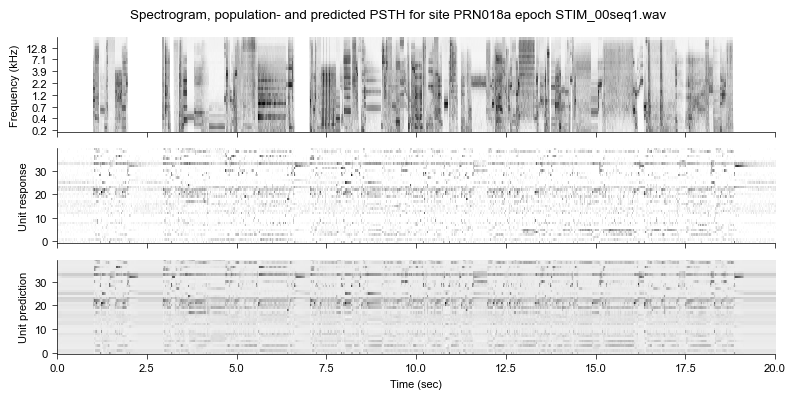

In [6]:
stim_epochs = val['stim'].epoch_names_matching("STIM_")

fs=val['stim'].fs
e=stim_epochs[0]

s = val['stim'].extract_epoch(e)[0]
r = val['resp'].extract_epoch(e).mean(axis=0)
p = val['pred'].extract_epoch(e).mean(axis=0)

f,ax=plt.subplots(3,1,sharex='col', figsize=(8,4))

loglo, loghi = np.log2(modelspec.meta['f_min']), np.log2(modelspec.meta['f_max'])
f_steps = np.round(2**np.linspace(loglo,loghi,s.shape[0])/1000,1)
T_max=s.shape[1]/fs
ax[0].imshow(s, aspect='auto', cmap='gray_r', origin='lower', extent=[0, T_max, -0.5, s.shape[0]-0.5])
ax[0].set_yticks(np.arange(0,s.shape[0],4), f_steps[np.arange(0,s.shape[0],4)])
ax[0].set_ylabel('Frequency (kHz)')
ax[1].imshow(r, aspect='auto', cmap='gray_r', extent=[0, T_max, -0.5, r.shape[0]-0.5])
ax[1].set_ylabel('Unit response')
ax[2].imshow(p, aspect='auto', cmap='gray_r', extent=[0, T_max, -0.5, p.shape[0]-0.5])
ax[2].set_ylabel('Unit prediction')
ax[2].set_xlabel('Time (sec)')
f.suptitle(f"Spectrogram, population- and predicted PSTH for site {siteid} epoch {e}")
plt.tight_layout()

# Fit and compare LN and CNN-based models

## Format data for fitting

Data matrices should be structured batch X time X \<other dims\>

In [7]:
X_est = np.moveaxis(est['stim'].extract_epoch("REFERENCE"), 1, 2)
Y_est = np.moveaxis(est['resp'].extract_epoch("REFERENCE"), 1, 2)
X_val = np.moveaxis(val['stim'].extract_epoch("REFERENCE"), 1, 2)
Y_val = np.moveaxis(val['resp'].extract_epoch("REFERENCE"), 1, 2)
print(f"Fit stimulus shape (batch X time X freq. channels): {X_est.shape}")
print(f"Fit response shape (batch X time X units): {Y_est.shape}")
print(f"Test stimulus shape (batch X time X freq. channels): {X_val.shape}")
print(f"Test response shape (batch X time X units): {Y_val.shape}")

cellids = est['resp'].chans
cellcount = len(cellids)

fs = est['resp'].fs
print(f"Sampling rate {fs}/sec makes trial len {X_est.shape[1]/fs} sec")
f_min, f_max = 200, 20000

Fit stimulus shape (batch X time X freq. channels): (250, 2000, 32)
Fit response shape (batch X time X units): (250, 2000, 40)
Test stimulus shape (batch X time X freq. channels): (6, 2000, 32)
Test response shape (batch X time X units): (6, 2000, 40)
Sampling rate 100/sec makes trial len 20.0 sec


Set some basic model and fit parameters that will be used for both the LN and CNN model

In [8]:
gaussian = False
rank = 50
regularizer = 'l2:4'
architecture='CNN'
layer2_size = 60

learning_rate = 1e-4

# this is a very conservative stop threshold. Runs fast but underfits.
#early_stopping_tolerance = 1e-3

# more realistic stop threshold
early_stopping_tolerance = 1e-4


In [9]:
# two-stage coarse-to-fine fit routine

def fit_LBHB(model0, X, Y, cost_function='nmse', fitter='tf',
             learning_rate=1e-3, epochs=8000, early_stopping_tolerance=1e-4):

    """
    2-stage coarse-to-fine fit with removing NL on first stage.
    """

    fitter_options = {'cost_function': cost_function,  # 'nmse'
                      'early_stopping_tolerance': early_stopping_tolerance*10,
                      'validation_split': 0,
                      'learning_rate': learning_rate*10, 'epochs': int(epochs/2)
                      }
    fitter_options2 = {'cost_function': cost_function,
                       'early_stopping_tolerance': early_stopping_tolerance,
                       'validation_split': 0,
                       'learning_rate': learning_rate, 'epochs': epochs

                       }
    model = model0.sample_from_priors()

    model.layers[-1].skip_nonlinearity()
    model = model.fit(input=X, target=Y, backend=fitter,
                    fitter_options=fitter_options, batch_size=None)
    model.layers[-1].unskip_nonlinearity()
    model = model.fit(input=X, target=Y, backend=fitter,
                      verbose=0, fitter_options=fitter_options2, batch_size=None)

    ymin, ymax = Y.min(axis=tuple(range(Y.ndim - 1))), Y.max(axis=tuple(range(Y.ndim - 1)))
    ydelta = (ymax - ymin) * 0.1
    model.out_range = [ymin - ydelta, ymax + ydelta]

    return model


## Initialize and fit LN model


In [10]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

2026-01-21 15:19:00.199388: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-21 15:19:00.219166: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-21 15:19:00.219190: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-21 15:19:00.220006: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-21 15:19:00.224126: I tensorflow/core/platform/cpu_feature_guar

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-01-21 15:19:02.211009: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-01-21 15:19:02.237577: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-01-21 15:19:02.239021: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [11]:
modelparms = {'time_bins': 20, 'channels_in': 32,
             'channels_out': cellcount, 'rank': rank, 'share_tuning': True,
             'gaussian': gaussian, 'fs': fs, 'stride': 1, 
             'regularizer': regularizer, 'f_min': f_min, 'f_max': f_max}

model_ln0 = LN.LN_pop(name=f"LN_{siteid}_g{gaussian}_r{rank}_s{modelparms['stride']}_{cellcount}cells", **modelparms)
model_ln0.meta['cellids']=cellids

# Random initial parameters
model_ln0 = model_ln0.sample_from_priors()

# actually perform the fit
model_ln = fit_LBHB(model_ln0, X_est, Y_est, learning_rate=learning_rate,
                    early_stopping_tolerance=early_stopping_tolerance)


2026-01-21 15:19:04.516200: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-01-21 15:19:04.520371: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-01-21 15:19:04.522010: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

1 Physical GPUs, 1 Logical GPUs


[nems.backends.tf.backend INFO]  nelsTF)                                                         
[nems.backends.tf.backend INFO]  FiniteImpulseResponse (Fin  (None, 2000, 50)          1000      
[nems.backends.tf.backend INFO]  iteImpulseResponseTF)                                           
[nems.backends.tf.backend INFO]  WeightChannels0 (WeightCha  (None, 2000, 40)          2000      
[nems.backends.tf.backend INFO]  nnelsTF)                                                        
[nems.backends.tf.backend INFO]  DoubleExponential (StaticN  (None, 2000, 40)          160       
[nems.backends.tf.backend INFO]  onlinearityTF)                                                  
[nems.backends.tf.backend INFO] =================================================================
[nems.backends.tf.backend INFO] Total params: 4760 (18.59 KB)
[nems.backends.tf.backend INFO] Trainable params: 4640 (18.12 KB)
[nems.backends.tf.backend INFO] Non-trainable params: 120 (480.00 Byte)
[nems.backends.t

~~~~~~~~~~~~~~~Using grad_clipnorm=1.0


2026-01-21 15:19:05.640360: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-01-21 15:19:05.983991: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-01-21 15:19:06.033910: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
[nems.backends.tf.backend INFO] Init loss: 1.457, tol: 0.001, batch_size: None, shuffle: False
2026-01-21 15:19:08.238856: I external/local_xla/xla/service/service.cc:168] XLA service 0x7328728e1f50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-21 15:19:08.238879: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Ti, Compute Capability 8.9
2026-01-21 15:19:08.241928: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `

...

[nems.backends.tf.backend INFO] Final loss: 0.8782
[nems.backends.tf.backend INFO] Applying regularizer l2:4 (p=0.0001) to WeightChannels
[nems.backends.tf.backend INFO] Applying regularizer l2:4 (p=0.0001) to FiniteImpulseResponse
[nems.backends.tf.backend INFO] Applying regularizer l2:4 (p=0.0001) to WeightChannels0
[nems.backends.tf.backend INFO] TF model built. (verbose=0)
[nems.backends.tf.backend INFO] Starting tf.backend.fit...
[nems.backends.tf.backend INFO] Cost function: nmse
[nems.backends.tf.backend INFO] TF model compiled


~~~~~~~~~~~~~~~Using grad_clipnorm=1.0


[nems.backends.tf.backend INFO] Init loss: 1.616, tol: 0.0001, batch_size: None, shuffle: False
[nems.backends.tf.backend INFO] Epoch 0000/8000 - loss: 1.6092
[nems.backends.tf.backend INFO] Epoch 0050/8000 - loss: 1.0093
[nems.backends.tf.backend INFO] Epoch 0100/8000 - loss: 0.9572
[nems.backends.tf.backend INFO] Epoch 0150/8000 - loss: 0.9218
[nems.backends.tf.backend INFO] Epoch 0200/8000 - loss: 0.9005
[nems.backends.tf.backend INFO] Epoch 0250/8000 - loss: 0.8896
[nems.backends.tf.backend INFO] Epoch 0300/8000 - loss: 0.8846
[nems.backends.tf.backend INFO] Epoch 0350/8000 - loss: 0.8825
[nems.backends.tf.backend INFO] Epoch 0400/8000 - loss: 0.8816
[nems.backends.tf.backend INFO] Epoch 0450/8000 - loss: 0.8811
[nems.backends.tf.backend INFO] Epoch 0500/8000 - loss: 0.8807
[nems.backends.tf.backend INFO] Epoch 0550/8000 - loss: 0.8804
[nems.backends.tf.backend INFO] Epoch 0600/8000 - loss: 0.8800
[nems.backends.tf.backend INFO] Epoch 0650/8000 - loss: 0.8797
[nems.backends.tf.back

Restoring model weights from the end of the best epoch: 3709.
Epoch 3859: early stopping


[nems.backends.tf.backend INFO] Final loss: 0.8699


Test prediction accuracy

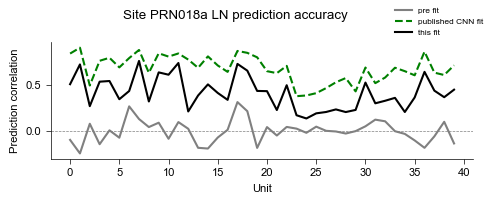

In [12]:
pred0 = model_ln0.predict(X_val, batch_size=X_val.shape[0])
pred = model_ln.predict(X_val, batch_size=X_val.shape[0])

r_test0 = correlation(pred0, Y_val)
r_test = correlation(pred, Y_val)

model_ln.meta['r_test0'] = r_test0[:, np.newaxis]
model_ln.meta['r_test'] = r_test[:, np.newaxis]

f,ax = plt.subplots(figsize=(5,2))
ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.plot(r_test0, color='gray', label='pre fit')
ax.plot(r_test_pub, 'g--', label='published CNN fit')
ax.plot(r_test, color='black', label='this fit')
ax.set_ylabel('Prediction correlation')
ax.set_xlabel('Unit')
f.suptitle(f"Site {siteid} LN prediction accuracy")
f.legend()
f.tight_layout()

## Fit CNN-based model

In [13]:
# intialize
modelparms = {'time_bins': 15, 'channels_in': 32,
              'L2': layer2_size, 'L1_reps': 2, 
              'channels_out': cellcount, 'rank': rank, 'share_tuning': True,
              'gaussian': gaussian, 'fs': fs, 'stride': 1, 
              'regularizer': regularizer, 'f_min': f_min, 'f_max': f_max}

model_cnn0 = CNN.CNN_pop(name=f"CNN_{siteid}_g{gaussian}_r{rank}_l{layer2_size}_s{modelparms['stride']}_{cellcount}cells", **modelparms)
model_cnn0.meta['cellids'] = cellids

model_cnn0

CNN_pop()
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
WeightChannels(shape=(32, 1, 50), norm_coefficients=False)
Parameter(name=coefficients, shape=(32, 1, 50))

FiniteImpulseResponse(shape=(15, 1, 50), stride=1, include_anticausal=False, fshape=(15, 1, 50))
Parameter(name=coefficients, shape=(15, 1, 50))

RectifiedLinear(shape=(50,), normalize_output=False, no_shift=False, no_offset=True, no_gain=True)
Parameter(name=shift, shape=(50,))
----------------
Parameter(name=offset, shape=(50,))
----------------
Parameter(name=gain, shape=(50,))

WeightChannels(shape=(50, 1, 50), norm_coefficients=False)
Parameter(name=coefficients, shape=(50, 1, 50))

FiniteImpulseResponse(shape=(15, 1, 50), stride=1, include_anticausal=False, fshape=(15, 1, 50))
Parameter(name=coefficients, shape=(15, 1, 50))

RectifiedLinear(shape=(50,), normalize_output=False, no_shift=False, no_offset=True, no_gain=True)
Parameter(name=shift, shape=(50,))
----------------
Parameter(name=offset, shap

In [14]:
# actually perform the fit
model_cnn = fit_LBHB(model_cnn0, X_est, Y_est, learning_rate=learning_rate,
                     early_stopping_tolerance=early_stopping_tolerance)

[nems.backends.tf.backend INFO] Applying regularizer l2:4 (p=0.0001) to WeightChannels
[nems.backends.tf.backend INFO] Applying regularizer l2:4 (p=0.0001) to FiniteImpulseResponse
[nems.backends.tf.backend INFO] Applying regularizer l2:4 (p=0.0001) to WeightChannels0
[nems.backends.tf.backend INFO] Applying regularizer l2:4 (p=0.0001) to FiniteImpulseResponse0
[nems.backends.tf.backend INFO] Applying regularizer l2:4 (p=0.0001) to WeightChannels1
[nems.backends.tf.backend INFO] Applying regularizer l2:4 (p=0.0001) to WeightChannels2
[nems.backends.tf.backend INFO] TF model built. (verbose=1)
[nems.backends.tf.backend INFO] Model: "CNN_PRN018a_gFalse_r50_l60_s1_40cells"
[nems.backends.tf.backend INFO] _________________________________________________________________
[nems.backends.tf.backend INFO]  Layer (type)                Output Shape              Param #   
[nems.backends.tf.backend INFO] =================================================================
[nems.backends.tf.backend I

~~~~~~~~~~~~~~~Using grad_clipnorm=1.0


[nems.backends.tf.backend INFO] Init loss: 1.602, tol: 0.001, batch_size: None, shuffle: False
[nems.backends.tf.backend INFO] Epoch 0000/4000 - loss: 1.3390
[nems.backends.tf.backend INFO] Epoch 0050/4000 - loss: 0.8834
[nems.backends.tf.backend INFO] Epoch 0100/4000 - loss: 0.8704
[nems.backends.tf.backend INFO] Epoch 0150/4000 - loss: 0.8658
[nems.backends.tf.backend INFO] Epoch 0200/4000 - loss: 0.8630
[nems.backends.tf.backend INFO] Epoch 0250/4000 - loss: 0.8609
[nems.backends.tf.backend INFO] Epoch 0300/4000 - loss: 0.8595
[nems.backends.tf.backend INFO] Epoch 0350/4000 - loss: 0.8582
[nems.backends.tf.backend INFO] Epoch 0400/4000 - loss: 0.8569
[nems.backends.tf.backend INFO] Epoch 0450/4000 - loss: 0.8560
[nems.backends.tf.backend INFO] Epoch 0500/4000 - loss: 0.8545
[nems.backends.tf.backend INFO] Epoch 0550/4000 - loss: 0.8537
[nems.backends.tf.backend INFO] Epoch 0600/4000 - loss: 0.8533
[nems.backends.tf.backend INFO] Epoch 0650/4000 - loss: 0.8527
[nems.backends.tf.backe

Restoring model weights from the end of the best epoch: 647.
Epoch 797: early stopping


[nems.backends.tf.backend INFO] Final loss: 0.8518
[nems.backends.tf.backend INFO] Applying regularizer l2:4 (p=0.0001) to WeightChannels
[nems.backends.tf.backend INFO] Applying regularizer l2:4 (p=0.0001) to FiniteImpulseResponse
[nems.backends.tf.backend INFO] Applying regularizer l2:4 (p=0.0001) to WeightChannels0
[nems.backends.tf.backend INFO] Applying regularizer l2:4 (p=0.0001) to FiniteImpulseResponse0
[nems.backends.tf.backend INFO] Applying regularizer l2:4 (p=0.0001) to WeightChannels1
[nems.backends.tf.backend INFO] Applying regularizer l2:4 (p=0.0001) to WeightChannels2
[nems.backends.tf.backend INFO] TF model built. (verbose=0)
[nems.backends.tf.backend INFO] Starting tf.backend.fit...
[nems.backends.tf.backend INFO] Cost function: nmse
[nems.backends.tf.backend INFO] TF model compiled


~~~~~~~~~~~~~~~Using grad_clipnorm=1.0


[nems.backends.tf.backend INFO] Init loss: 1.526, tol: 0.0001, batch_size: None, shuffle: False
[nems.backends.tf.backend INFO] Epoch 0000/8000 - loss: 1.5159
[nems.backends.tf.backend INFO] Epoch 0050/8000 - loss: 0.9067
[nems.backends.tf.backend INFO] Epoch 0100/8000 - loss: 0.8822
[nems.backends.tf.backend INFO] Epoch 0150/8000 - loss: 0.8750
[nems.backends.tf.backend INFO] Epoch 0200/8000 - loss: 0.8701
[nems.backends.tf.backend INFO] Epoch 0250/8000 - loss: 0.8669
[nems.backends.tf.backend INFO] Epoch 0300/8000 - loss: 0.8644
[nems.backends.tf.backend INFO] Epoch 0350/8000 - loss: 0.8626
[nems.backends.tf.backend INFO] Epoch 0400/8000 - loss: 0.8612
[nems.backends.tf.backend INFO] Epoch 0450/8000 - loss: 0.8601
[nems.backends.tf.backend INFO] Epoch 0500/8000 - loss: 0.8593
[nems.backends.tf.backend INFO] Epoch 0550/8000 - loss: 0.8587
[nems.backends.tf.backend INFO] Epoch 0600/8000 - loss: 0.8582
[nems.backends.tf.backend INFO] Epoch 0650/8000 - loss: 0.8578
[nems.backends.tf.back

Restoring model weights from the end of the best epoch: 5844.
Epoch 5994: early stopping


[nems.backends.tf.backend INFO] Final loss: 0.8487


Test prediction accuracy

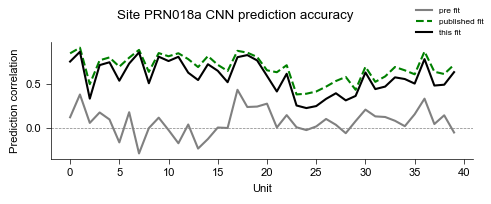

In [15]:
pred0 = model_cnn0.predict(X_val, batch_size=X_val.shape[0])
pred = model_cnn.predict(X_val, batch_size=X_val.shape[0])

r_test0 = correlation(pred0, Y_val)
r_test = correlation(pred, Y_val)

model_cnn.meta['r_test0'] = r_test0[:, np.newaxis]
model_cnn.meta['r_test'] = r_test[:, np.newaxis]

f,ax = plt.subplots(figsize=(5,2))
ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.plot(r_test0, color='gray', label='pre fit')
ax.plot(r_test_pub, 'g--', label='published fit')
ax.plot(r_test, color='black', label='this fit')
ax.set_ylabel('Prediction correlation')
ax.set_xlabel('Unit')
f.suptitle(f"Site {siteid} CNN prediction accuracy")
f.legend()
f.tight_layout()

## Compare LN and CNN prediction accuracy

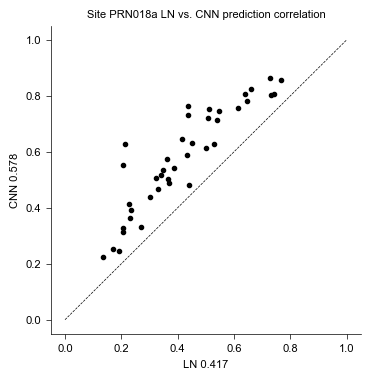

In [16]:
f,ax=plt.subplots(figsize=(4,4))
aud_ss_tools.scatter_comp(x=model_ln.meta['r_test'], y=model_cnn.meta['r_test'], 
                          n1='LN', n2='CNN', hist_range=[0,1.0], ax=ax);
ax.set_title(f"Site {siteid} LN vs. CNN prediction correlation");

# Single-neuron tuning subspace

## Compute dynamic spectro-temporal receptive field (dSTRF)

In [17]:
# merge batch and time dimensions
stim = np.reshape(X_est, (X_est.shape[0]*X_est.shape[1], -1))

F = stim.shape[1]
D = 20
out_channels = np.arange(cellcount)  # compute for all units in model
t_indexes = np.arange(D, stim.shape[0], 101)
print(f"Measuring dSTRF using stimulus at {len(t_indexes)} timepoints.")

d_ = model_cnn.dstrf(stim, D=D, out_channels=out_channels, t_indexes=t_indexes, reset_backend=False)
d = d_['input']


[nems.backends.tf.backend INFO] Applying regularizer l2:4 (p=0.0001) to WeightChannels
[nems.backends.tf.backend INFO] Applying regularizer l2:4 (p=0.0001) to FiniteImpulseResponse
[nems.backends.tf.backend INFO] Applying regularizer l2:4 (p=0.0001) to WeightChannels0
[nems.backends.tf.backend INFO] Applying regularizer l2:4 (p=0.0001) to FiniteImpulseResponse0
[nems.backends.tf.backend INFO] Applying regularizer l2:4 (p=0.0001) to WeightChannels1
[nems.backends.tf.backend INFO] Applying regularizer l2:4 (p=0.0001) to WeightChannels2
[nems.backends.tf.backend INFO] TF model built. (verbose=1)
[nems.backends.tf.backend INFO] Model: "CNN_PRN018a_gFalse_r50_l60_s1_40cells"
[nems.backends.tf.backend INFO] _________________________________________________________________
[nems.backends.tf.backend INFO]  Layer (type)                Output Shape              Param #   
[nems.backends.tf.backend INFO] =================================================================
[nems.backends.tf.backend I

Measuring dSTRF using stimulus at 4951 timepoints.


[tensorflow WARNING] Calling GradientTape.gradient on a persistent tape inside its context is significantly less efficient than calling it outside the context (it causes the gradient ops to be recorded on the tape, leading to increased CPU and memory usage). Only call GradientTape.gradient inside the context if you actually want to trace the gradient in order to compute higher order derivatives.


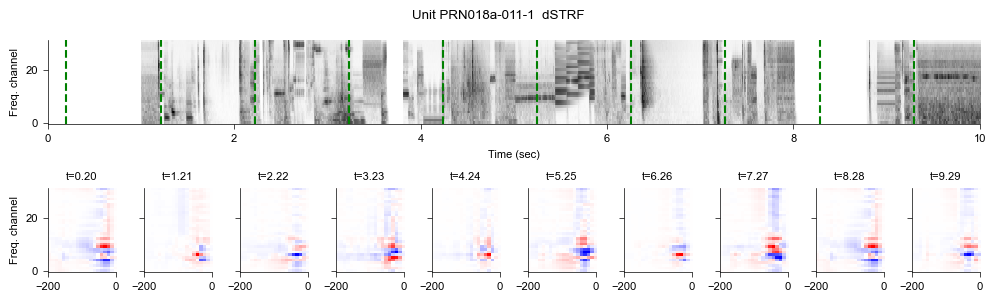

In [18]:
f = plt.figure(figsize=(10,3))
ax0 = f.add_subplot(2,1,1)
T=1000
ax0.imshow(stim[:T,:].T, cmap='gray_r', origin='lower', extent=[0, T/fs, -0.5, stim.shape[1]-0.5])
ax0.set_xlabel("Time (sec)")
ax0.set_ylabel("Freq. channel")
cid = 6
N=10
for i,t in enumerate(t_indexes[:N]):
    ax0.axvline(t/fs, ls='--', color='g')
    ax=f.add_subplot(2,N,N+1+i)
    ds = d[cid,i]
    mm = np.max(np.abs(ds))
    ax.imshow(ds, origin='lower', cmap='bwr', vmin=-mm, vmax=mm, extent=[-fs/0.5, (D-0.5)/fs, -0.5, ds.shape[0]-0.5])
    ax.set_title(f"t={t/fs:.2f}")
    if i>0:
        ax.set_yticklabels([])
    else:
        ax.set_ylabel("Freq. channel")

f.suptitle(f"Unit {cellids[cid]}  dSTRF")
f.tight_layout()

## Use PCA to compute subspace dimensions

In [19]:
snr_threshold = 5
pc_count = 5
dpc = np.zeros((cellcount, pc_count, F, D))
dpc_mag = np.zeros((cellcount, pc_count))

for c in range(cellcount):
    features = np.reshape(d[c, :, :, :], (d.shape[1], F * D))

    if snr_threshold is not None:
        mean_features = features.mean(axis=0, keepdims=True)
        noise = np.std(features - mean_features, axis=1) / np.std(mean_features)
    
        if (noise > snr_threshold).sum() > 0:
            print(f"Unit {c}: Removed {(noise>snr_threshold).sum()}/{len(features)} noisy dSTRFs for PCA calculation")
        fit_features = features[(noise <= snr_threshold), :]
    else:
        fit_features = features

    p = PCA(n_components=pc_count)
    p = p.fit(fit_features)
    components = p.components_
    variance = np.sqrt(p.explained_variance_ratio_)

    # make net sign positive to simplify visualization
    for i,c_ in enumerate(components):
        if c_.sum()<0:
            components[i] = -c_
    
    dpc[c, :, :, :] = np.reshape(components, [pc_count, F, D])
    
    dpc_mag[c, :] = variance[:pc_count]

model_cnn.meta['dpc']=dpc
model_cnn.meta['dpc_mag']=dpc_mag

Unit 3: Removed 14/4951 noisy dSTRFs for PCA calculation
Unit 4: Removed 81/4951 noisy dSTRFs for PCA calculation
Unit 6: Removed 2/4951 noisy dSTRFs for PCA calculation
Unit 11: Removed 3/4951 noisy dSTRFs for PCA calculation
Unit 14: Removed 1/4951 noisy dSTRFs for PCA calculation
Unit 15: Removed 307/4951 noisy dSTRFs for PCA calculation
Unit 18: Removed 9/4951 noisy dSTRFs for PCA calculation


## Plot subspace projection for example unit

Project stimulus spectrogram into subspace

In [20]:
def apply_strf(stim, h):
    """
    project stim into a subspace dimension defined by spectro-temporal filter h
    """
    D=h.shape[0]
    channel_out = [np.convolve(s, row)[:-D+1] for s,row in zip(stim.T, h.T)]
    y = np.sum(np.stack(channel_out,axis=1),axis=1)
    return y

cid = 6
xhat = np.zeros((stim.shape[0],pc_count))
for i in range(pc_count):
    xhat[:,i]=apply_strf(stim, np.flipud(dpc[cid,i].T))

pred = model_cnn.predict(stim)


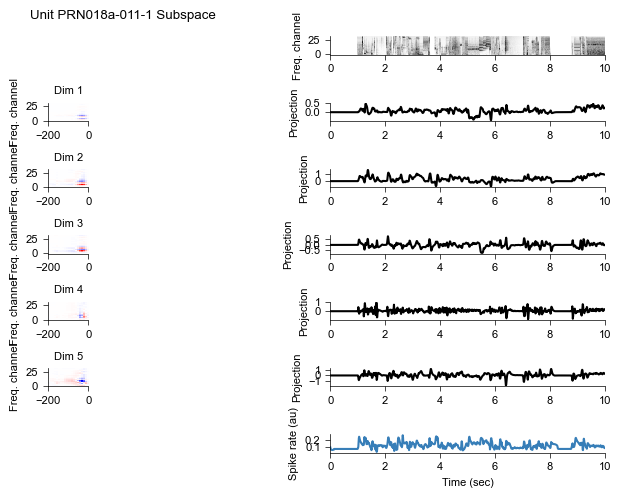

In [21]:
f = plt.figure(figsize=(10,5))

T = 1000

ax0 = f.add_subplot(pc_count+2,2,2)
ax0.imshow(stim[:T,:].T, cmap='gray_r', origin='lower', extent=[0, T/fs, -0.5, stim.shape[1]-0.5])
ax0.set_ylabel("Freq. channel")

t = np.arange(T)/fs
axN = f.add_subplot(pc_count+2,2,2*(pc_count+2))
axN.plot(t,pred[:T,cid], color=aud_ss_tools.CB_color_cycle[0])
axN.set_xlim([0,T/fs])
axN.set_xlabel("Time (sec)")
axN.set_ylabel("Spike rate (au)")

for i in range(pc_count):
    ax=f.add_subplot(pc_count+2,10,10*(i+1)+5)
    
    ds = dpc[cid, i]
    mm = np.max(np.abs(ds))
    ax.imshow(ds, origin='lower', cmap='bwr', vmin=-mm, vmax=mm, extent=[-fs/0.5, (D-0.5)/fs, -0.5, ds.shape[0]-0.5])
    ax.set_title(f"Dim {i+1}")
    ax.set_ylabel("Freq. channel")
    
    ax2=f.add_subplot(pc_count+2,2,2*(i+1)+2)
    ax2.plot(t,xhat[:T,i],'k')
    ax2.set_xlim([0,T/fs])
    ax2.set_ylabel("Projection")

f.suptitle(f"Unit {cellids[cid]} Subspace")
f.tight_layout()

## Plot SSRF for example unit

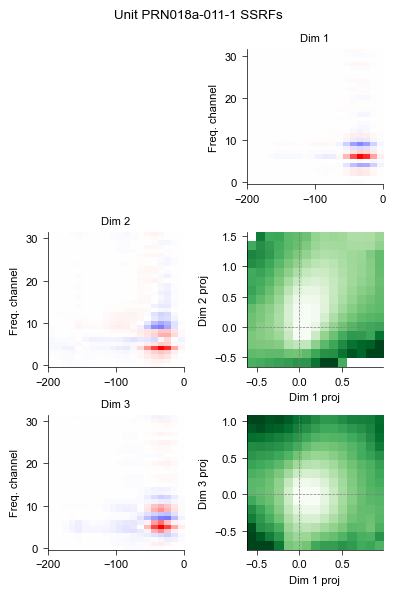

In [22]:
f, ax = plt.subplots(3,2, figsize=(4,6))
ax[0,0].set_axis_off()

dax = [ax[0,1], ax[1,0], ax[2,0]]
hax = [ax[1,1], ax[2,1]]

for i in range(3):
    ds = dpc[cid, i]
    mm = np.max(np.abs(ds))
    dax[i].imshow(ds, origin='lower', cmap='bwr', vmin=-mm, vmax=mm, extent=[-fs/0.5, (D-0.5)/fs, -0.5, ds.shape[0]-0.5])
    dax[i].set_title(f"Dim {i+1}")
    dax[i].set_ylabel("Freq. channel")

for i in range(3-1):
    aud_ss_tools.histmean2d(xhat[:,0], xhat[:,i+1], pred[:,cid], bins=15, cmap='Greens', ax=hax[i]);
    hax[i].set_xlabel('Dim 1 proj')
    hax[i].set_ylabel(f'Dim {i+2} proj')

f.suptitle(f"Unit {cellids[cid]} SSRFs")
f.tight_layout()

# Site-wide tuning subspace and SSRF overlap

Use dSTRFs computed in previous section, perform PCA across all units to compute subspace for entire recording site

In [23]:
features = d.reshape((cellcount*d.shape[1], F*D))
pc_count=10

p = PCA(n_components=pc_count)
p = p.fit(fit_features)
components = p.components_
variance = np.sqrt(p.explained_variance_ratio_)

# make net sign positive to simplify visualization
for i,c_ in enumerate(components):
    if c_.sum()<0:
        components[i] = -c_

dpc_all = np.reshape(components, [pc_count, F, D])
dpc_mag_all = variance[:pc_count]


## Plot site-wide subspace projection

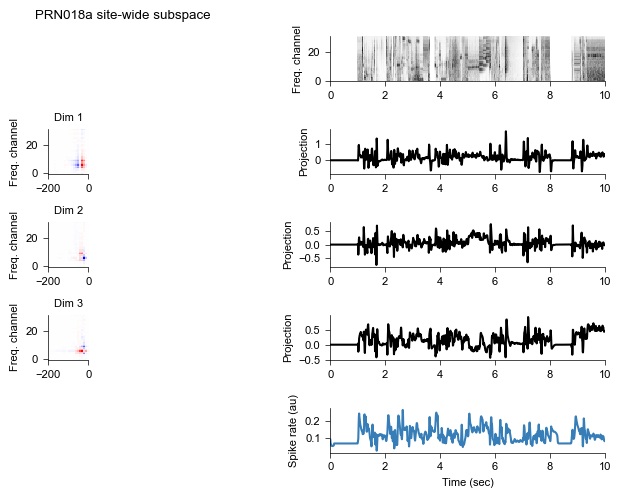

In [24]:
site_xhat = np.zeros((stim.shape[0],pc_count))
for i in range(pc_count):
    site_xhat[:,i]=apply_strf(stim, np.flipud(dpc_all[i].T))

f = plt.figure(figsize=(10,5))

T = 1000
show_pcs = 3

ax0 = f.add_subplot(show_pcs+2,2,2)
ax0.imshow(stim[:T,:].T, cmap='gray_r', origin='lower', extent=[0, T/fs, -0.5, stim.shape[1]-0.5])
ax0.set_ylabel("Freq. channel")

t = np.arange(T)/fs
axN = f.add_subplot(show_pcs+2,2,2*(show_pcs+2))
axN.plot(t,pred[:T,cid], color=aud_ss_tools.CB_color_cycle[0])
axN.set_xlim([0,T/fs])
axN.set_xlabel("Time (sec)")
axN.set_ylabel("Spike rate (au)")

for i in range(show_pcs):
    ax=f.add_subplot(show_pcs+2,10,10*(i+1)+5)
    
    ds = dpc_all[i]
    mm = np.max(np.abs(ds))
    ax.imshow(ds, origin='lower', cmap='bwr', vmin=-mm, vmax=mm, extent=[-fs/0.5, (D-0.5)/fs, -0.5, ds.shape[0]-0.5])
    ax.set_title(f"Dim {i+1}")
    ax.set_ylabel("Freq. channel")
    
    ax2=f.add_subplot(show_pcs+2,2,2*(i+1)+2)
    ax2.plot(t,site_xhat[:T,i],'k')
    ax2.set_xlim([0,T/fs])
    ax2.set_ylabel("Projection")

f.suptitle(f"{siteid} site-wide subspace")
f.tight_layout()

## Plot SSRFs in site-wide subspace

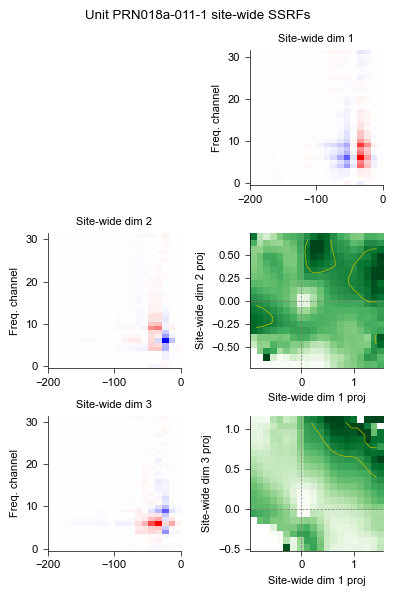

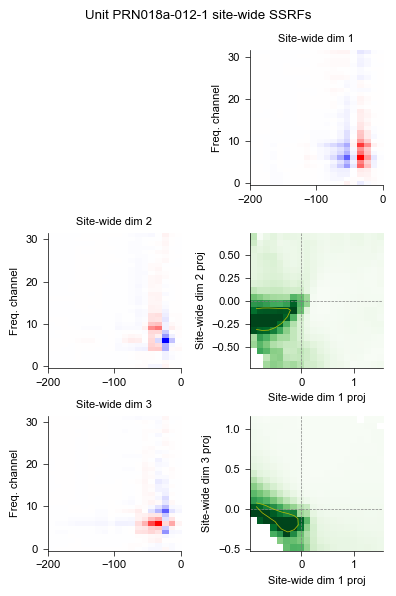

In [25]:
Nmin=5
level=[0.8]
for cid in [6,7]:
    f, ax = plt.subplots(3,2, figsize=(4,6))
    ax[0,0].set_axis_off()
    
    dax = [ax[0,1], ax[1,0], ax[2,0]]
    hax = [ax[1,1], ax[2,1]]
    
    for i in range(show_pcs):
        ds = dpc_all[i]
        mm = np.max(np.abs(ds))
        dax[i].imshow(ds, origin='lower', cmap='bwr', vmin=-mm, vmax=mm, extent=[-fs/0.5, (D-0.5)/fs, -0.5, ds.shape[0]-0.5])
        dax[i].set_title(f"Site-wide dim {i+1}")
        dax[i].set_ylabel("Freq. channel")
    
    for i in range(show_pcs-1):
        ac, bc, Z, N = aud_ss_tools.histmean2d(site_xhat[:,0], site_xhat[:,i+1], pred[:,cid], bins=20, cmap='Greens', ax=hax[i]);
        hax[i].set_xlabel('Site-wide dim 1 proj')
        hax[i].set_ylabel(f'Site-wide dim {i+2} proj')

        Znan = np.isnan(Z)
        Z = Z - np.nanmin(Z)
        Z[Znan]=0
        Z = smooth(Z, window_len=5, axis=(0, 1))
        Z[N<Nmin] = 0
        Z = Z / np.max(Z)
    
        hax[i].contour(ac, bc, Z, levels=level + [1], colors=['y'], linewidths=0.5)

    
    f.suptitle(f"Unit {cellids[cid]} site-wide SSRFs")
    f.tight_layout()


In [26]:
rthr=0.4
goodidx = [i for i in range(cellcount) if model_cnn.meta['r_test'][i,0]>rthr]
print(f"{len(goodidx)}/{cellcount} high-pred units")

32/40 high-pred units


In [27]:
p1, p2 = 0, 1
bins=15
ex_pct=0.01
fill_colors=None
outline_colors=None
level=[0.8]

Zall = np.zeros((len(goodidx), bins, bins))
Zshall = np.zeros((len(goodidx), bins, bins))
Nbins = np.zeros(len(cellids), dtype=int)

Nmin=5

for ii,cid in enumerate(goodidx):
    print(f"{ii} {cellids[cid]}")
    ac, bc, Z, N = aud_ss_tools.histmean2d(site_xhat[:,p1], site_xhat[:,p2], pred[:,cid], bins=bins, ex_pct=ex_pct, show_plot=False)
    Znan = np.isnan(Z)
    Z = Z - np.nanmin(Z)
    Z[Znan]=0
    Z = smooth(Z, window_len=5, axis=(0, 1))
    Z[N<Nmin] = 0
    Z = Z / np.max(Z)
    Zall[ii] = Z
    Zshall[ii] = np.roll(Z,np.random.randint(20, size=2), axis=(0, 1))
    
    if ii == 0:
        Zlist = np.zeros_like(Z, dtype=int)
        randcount = 10
        Zshlist = np.zeros(list(Z.shape)+[randcount], dtype=int)
        Nlist = np.zeros_like(N)
    Nbins[ii] = (Z >= level[0]).sum()
    if Nbins[ii] in [0,360]:
        print(f"weird Nbins value?")
    Zlist = Zlist + (Z >= level[0]).astype(int)
    for rr in range(randcount):
        #Zsh = np.random.permutation(Z.flatten()).reshape(Z.shape)
        Zsh = np.roll(Z,np.random.randint(20, size=2), axis=(0, 1))
        Zshlist[:, :, rr] = Zshlist[:,:,rr] + (Zsh >= level[0]).astype(int)


0 PRN018a-003-1
1 PRN018a-006-1
2 PRN018a-009-1
3 PRN018a-010-1
4 PRN018a-010-2
5 PRN018a-011-1
6 PRN018a-012-1
7 PRN018a-015-1
8 PRN018a-016-1
9 PRN018a-018-1
10 PRN018a-019-1
11 PRN018a-019-2
12 PRN018a-019-3
13 PRN018a-023-1
14 PRN018a-024-1
15 PRN018a-026-1
16 PRN018a-029-1
17 PRN018a-039-1
18 PRN018a-041-1
19 PRN018a-042-1
20 PRN018a-043-1
21 PRN018a-046-1
22 PRN018a-062-1
23 PRN018a-063-1
24 PRN018a-070-1
25 PRN018a-350-1
26 PRN018a-354-1
27 PRN018a-359-1
28 PRN018a-363-1
29 PRN018a-371-1
30 PRN018a-379-1
31 PRN018a-383-1


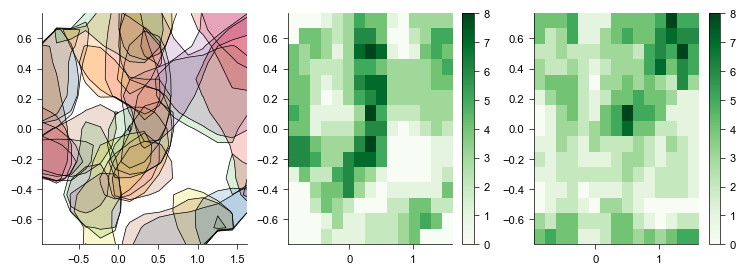

In [28]:
fill_colors=None
outline_colors=['k']*cellcount

f,ax = plt.subplots(1,3,figsize=(9,3))
for ii,cid in enumerate(goodidx):
    Z=Zall[ii]
    
    if fill_colors is None:
        colors = [aud_ss_tools.CB_color_cycle[ii % len(aud_ss_tools.CB_color_cycle)]] * (len(level) + 1)
    else:
        colors = fill_colors[ii]
    ax[0].contourf(ac, bc, Z, levels=level + [1], colors=colors, alpha=0.2)

    if outline_colors is not None:
        ax[0].contour(ac, bc, Z, levels=level + [1], colors=[outline_colors[ii]], linewidths=0.5)

Zsum = (Zall>0.8).sum(axis=0)
vmin, vmax = 0, Zsum.max()

im=ax[1].imshow(np.flipud(Zsum), cmap='Greens', extent=[ac[0], ac[-1], bc[0], bc[-1]], vmin=vmin, vmax=vmax)
plt.colorbar(im)

Zsum = (Zshall>0.8).sum(axis=0)
im=ax[2].imshow(np.flipud(Zsum), cmap='Greens', extent=[ac[0], ac[-1], bc[0], bc[-1]], vmin=vmin, vmax=vmax)
plt.colorbar(im)

